# Lecture 02: Introduction to deep learning

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §1.1-1.4 (Foundations and function approximation), §1.5-1.9 (Optimization, depth, and regularization), §1.10-1.11 (Generalization, sequence models)  
**Notebook role:** core  
**Author:** Simon Scheidegger  


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# The Double-Descent Phenomenon

> *"Bigger models are better models -- but only after they get worse first."*

Classical statistics predicts a clean **U-shaped** test-error curve as model
complexity grows: first the error falls (less bias), then it rises again
(more variance).  This is the textbook **bias-variance trade-off**.

Recent work reveals a striking extension.  When the number of
parameters $p$ exceeds the number of training samples $n$, test error
can *decrease again* -- a phenomenon called **double descent**
(Belkin et al., 2019; Nakkiran et al., 2019).

This notebook demonstrates double descent with a transparent,
minimal example using only NumPy.

---

**Outline**

1. Setup and data generation
2. Random Fourier features -- a tuneable model family
3. Sweeping model complexity $p$ and observing double descent
4. What happens to the weight vector?
5. Discussion

In [1]:
# ----------------------------------------------------------------
# Imports and plot style
# ----------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({
    "figure.dpi":       120,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.labelsize":   12,
    "legend.fontsize":  10,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "font.family":      "serif",
    "mathtext.fontset":  "cm",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
})

# Colour palette
C_TRAIN  = "#2a9d8f"
C_TEST   = "#e76f51"
C_THRESH = "#264653"
C_DATA   = "#457b9d"
C_NORM   = "#e9c46a"

np.random.seed(42)

---
## 1. Data generation

We create a simple regression task with $d = 5$ input features.
The true relationship uses only the first two coordinates:

$$
y = \sin(x_1) + \tfrac{1}{2}\cos(x_2) + \varepsilon,
\qquad \varepsilon \sim \mathcal{N}(0, 0.09)
$$

We use $n = 50$ training points and $500$ test points.

In [2]:
# ----------------------------------------------------------------
# Training and test data
# ----------------------------------------------------------------
d       = 5       # input dimension
n_train = 50      # training-set size
n_test  = 500
sigma_noise = 0.3

def true_fn(X):
    """Ground-truth function (uses only x_1 and x_2)."""
    return np.sin(X[:, 0]) + 0.5 * np.cos(X[:, 1])

X_train = np.random.randn(n_train, d)
y_train = true_fn(X_train) + sigma_noise * np.random.randn(n_train)

X_test  = np.random.randn(n_test, d)
y_test  = true_fn(X_test)            # noise-free ground truth

print(f"Training set:  {n_train} samples, {d} features")
print(f"Test set:      {n_test} samples")

Training set:  50 samples, 5 features
Test set:      500 samples


---
## 2. Random Fourier Features

To sweep model complexity continuously we use **Random Fourier
Features** (Rahimi & Recht, 2007).  Each input
$\mathbf{x} \in \mathbb{R}^d$ is mapped to a $p$-dimensional
feature vector

$$
\phi_j(\mathbf{x})
  = \sqrt{\frac{2}{p}}\,
    \cos\!\bigl(\boldsymbol{\omega}_j^\top \mathbf{x} + b_j\bigr),
\qquad j = 1,\dots,p
$$

where $\boldsymbol{\omega}_j \sim \mathcal{N}(\mathbf{0},
\sigma_\omega^2 \mathbf{I}_d)$ and $b_j \sim \mathrm{Uniform}(0,
2\pi)$.  The $\sqrt{2/p}$ prefactor keeps the feature scale
constant as $p$ grows.

We then solve the linear system
$\hat{y} = \Phi\,\boldsymbol{\theta}$ via `np.linalg.lstsq`,
which returns:

| Regime | What `lstsq` computes |
|:---|:---|
| $p < n$ | ordinary least squares (unique) |
| $p \ge n$ | **minimum-norm** solution among all interpolating $\boldsymbol{\theta}$ |

In [3]:
# ----------------------------------------------------------------
# Random Fourier Feature machinery
# ----------------------------------------------------------------
max_p     = 300
rff_sigma = 1.0     # bandwidth of the random projection

np.random.seed(0)   # fix the random features (independent of data seed)
W_all = np.random.randn(max_p, d) * rff_sigma
b_all = np.random.uniform(0, 2 * np.pi, max_p)


def rff_matrix(X, p):
    """Build the (n x p) random Fourier feature matrix."""
    return np.cos(X @ W_all[:p].T + b_all[np.newaxis, :p]) * np.sqrt(2.0 / p)

---
## 3. Sweeping model complexity

We fit the model for every $p = 1, 2, \dots, 300$ and record
training MSE, test MSE, and the norm of the weight vector.

In [4]:
# ----------------------------------------------------------------
# Compute train / test MSE and weight norm for each p
# ----------------------------------------------------------------
p_values   = np.arange(1, max_p + 1)
train_mse  = np.empty(max_p)
test_mse   = np.empty(max_p)
theta_norm = np.empty(max_p)

for i, p in enumerate(p_values):
    Phi_tr = rff_matrix(X_train, p)
    Phi_te = rff_matrix(X_test,  p)

    theta, *_ = np.linalg.lstsq(Phi_tr, y_train, rcond=None)

    train_mse[i]  = np.mean((y_train - Phi_tr @ theta) ** 2)
    test_mse[i]   = np.mean((y_test  - Phi_te @ theta) ** 2)
    theta_norm[i] = np.linalg.norm(theta)

print(f"Sweep complete: p = 1 ... {max_p}")
print(f"Peak test MSE = {test_mse.max():.2f} at p = {p_values[test_mse.argmax()]}")
print(f"Final test MSE at p = {max_p}: {test_mse[-1]:.4f}")

Sweep complete: p = 1 ... 300
Peak test MSE = 2.70 at p = 47
Final test MSE at p = 300: 0.2369


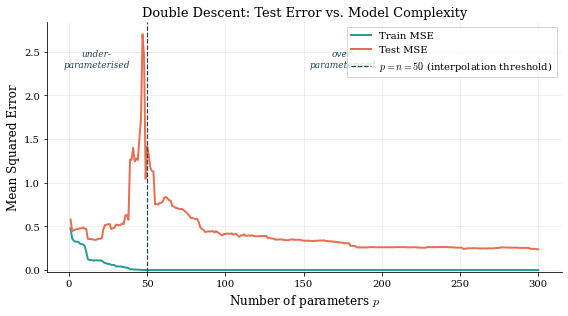

In [5]:
# ----------------------------------------------------------------
# Main figure: the double-descent curve
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(p_values, train_mse, lw=2, color=C_TRAIN, label="Train MSE")
ax.plot(p_values, test_mse,  lw=2, color=C_TEST,  label="Test MSE")

# Interpolation threshold
ax.axvline(n_train, ls="--", lw=1.2, color=C_THRESH,
           label=f"$p = n = {n_train}$ (interpolation threshold)")

# Cap y-axis so the spike does not crush the rest
y_cap = min(5.0, test_mse.max() * 1.05)
ax.set_ylim(-0.02, y_cap)

# Regime annotations
ax.annotate("under-\nparameterised",
            xy=(n_train * 0.35, y_cap * 0.82),
            fontsize=9, ha="center", color=C_THRESH, style="italic")
ax.annotate("over-\nparameterised",
            xy=(n_train * 3.5, y_cap * 0.82),
            fontsize=9, ha="center", color=C_THRESH, style="italic")

ax.set_xlabel("Number of parameters $p$")
ax.set_ylabel("Mean Squared Error")
ax.set_title("Double Descent: Test Error vs. Model Complexity")
ax.legend(loc="upper right", frameon=True, fancybox=False, edgecolor="0.8")
fig.tight_layout()
plt.show()

---
## 4. What happens to the weight vector?

The plot below shows $\lVert\boldsymbol{\theta}\rVert_2$ as a
function of $p$.  Near the interpolation threshold the model is
forced to use enormous weights to fit the noisy data exactly.
Once $p \gg n$ the minimum-norm constraint selects a solution with
much smaller weights -- and this smoother solution generalises better.

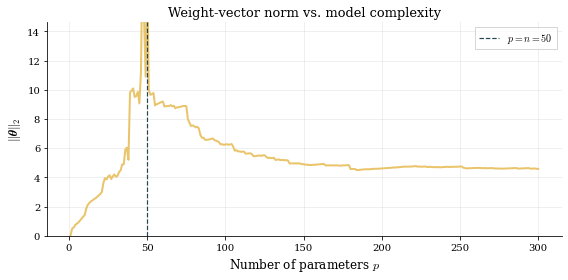

In [6]:
# ----------------------------------------------------------------
# Weight norm vs. model complexity
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(p_values, theta_norm, lw=2, color=C_NORM)
ax.axvline(n_train, ls="--", lw=1.2, color=C_THRESH,
           label=f"$p = n = {n_train}$")

# Cap for readability
norm_cap = min(np.percentile(theta_norm, 99) * 1.3, theta_norm.max())
ax.set_ylim(0, norm_cap)

ax.set_xlabel("Number of parameters $p$")
ax.set_ylabel(r"$\|\boldsymbol{\theta}\|_2$")
ax.set_title("Weight-vector norm vs. model complexity")
ax.legend(frameon=True, fancybox=False, edgecolor="0.8")
fig.tight_layout()
plt.show()

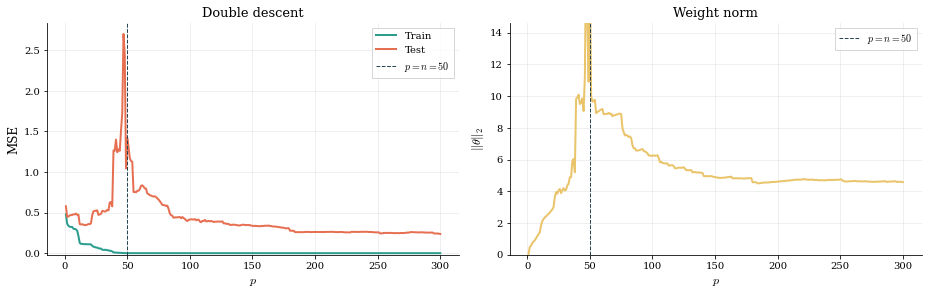

In [7]:
# ----------------------------------------------------------------
# Combined view: MSE and weight norm side by side
# ----------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

# Left: MSE
ax1.plot(p_values, train_mse, lw=2, color=C_TRAIN, label="Train")
ax1.plot(p_values, test_mse,  lw=2, color=C_TEST,  label="Test")
ax1.axvline(n_train, ls="--", lw=1, color=C_THRESH, label=f"$p=n={n_train}$")
ax1.set_ylim(-0.02, min(5.0, test_mse.max() * 1.05))
ax1.set_xlabel("$p$")
ax1.set_ylabel("MSE")
ax1.set_title("Double descent")
ax1.legend(frameon=True, fancybox=False, edgecolor="0.8")

# Right: weight norm
ax2.plot(p_values, theta_norm, lw=2, color=C_NORM)
ax2.axvline(n_train, ls="--", lw=1, color=C_THRESH, label=f"$p=n={n_train}$")
ax2.set_ylim(0, min(np.percentile(theta_norm, 99)*1.3, theta_norm.max()))
ax2.set_xlabel("$p$")
ax2.set_ylabel(r"$\|\theta\|_2$")
ax2.set_title("Weight norm")
ax2.legend(frameon=True, fancybox=False, edgecolor="0.8")

fig.tight_layout()
plt.show()

---
## 5. Discussion

### The three regimes

| Regime | Description |
|:---|:---|
| $p \ll n$ | **Under-parameterised.** The model is too simple; high bias, low variance. |
| $p \approx n$ | **Interpolation threshold.** The model can *just barely* fit the noisy training data.  The solution is extremely sensitive to the noise -- maximum variance, peak test error, and enormous weight norm. |
| $p \gg n$ | **Over-parameterised.** Many weight vectors interpolate the data.  The minimum-norm solution ($\min\lVert\boldsymbol{\theta}\rVert$) is the *smoothest* interpolant.  Test error and weight norm both decrease. |

### Why does this matter for deep learning?

Modern neural networks are massively over-parameterised ($p \gg n$)
yet generalise remarkably well.  Double descent helps explain why:

- **Overparameterisation is not the enemy.**  Once past the
  interpolation threshold, adding more parameters *helps*.
- **Implicit regularisation** from SGD, weight decay, and early
  stopping selects solutions with small norm -- analogous to the
  minimum-norm solution we computed here.
- The dangerous zone is $p \approx n$.  In practice, practitioners
  either stay well below it (classical regime) or go well above it
  (modern regime).

### Key references

- M. Belkin, D. Hsu, S. Ma, S. Mandal (2019).
  *Reconciling modern machine-learning practice and the classical
  bias-variance trade-off.*  PNAS 116(32), 15849-15854.
- P. Nakkiran, G. Kaplun, Y. Bansal, T. Yang, B. Barak, I. Sutskever
  (2019).  *Deep double descent: where bigger models and more data can
  hurt.*  arXiv:1912.02292.
- T. Hastie, A. Montanari, S. Rosset, R. J. Tibshirani (2022).
  *Surprises in high-dimensional ridgeless least squares interpolation.*
  Annals of Statistics 50(2), 949-986.